In [6]:
## 0. Importy
# Poniższe importy są wymagane do uruchomienia
# zadań 1-4. Zadanie 5 posiada osobne importy.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.datasets import load_wine
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

wine = load_wine(as_frame=True)
data = wine.frame
# print(data.head()) -- testy dla upewnienia się
# display(data)         że dane zostały odpowiednio wczytane

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [90]:
## 1.
# wczytaj zbiór danych wine
X, y = load_wine(return_X_y=True, as_frame=True)
y = (y == 0)

# podziel zbiór na treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# wytrenuj perceptron rozpoznający, czy obiekt należy do klasy 0
perceptron = Perceptron(random_state = 0)
perceptron.fit(X_train, y_train)

# wylicz dokładność na zbiorze testowym
acc_score = perceptron.score(X_test,y_test)
print("Accuracy: "+str(round(acc_score, 3)))

# wyświetl wartości wag oraz obciążenia
coef = perceptron.coef_
intercept = perceptron.intercept_
print(f'Coefficient: {coef}; \nIntercept: {intercept}')

# utwórz potok (pipeline)
mlp_classifier = MLPClassifier(hidden_layer_sizes=[10], max_iter=1000, random_state=42)
pipeline = make_pipeline(StandardScaler(), mlp_classifier)
pipeline.fit(X_train, y_train)
print(f'Pipeline Accuracy: {pipeline.score(X_test, y_test):.2}')

Accuracy: 0.898
Coefficient: [[-1327.58   -458.75   -259.03  -3428.8   -8846.      -28.7     216.84
    -77.65    -34.32   -689.88    -68.124   -37.14    952.   ]]; 
Intercept: [-124.]
Pipeline Accuracy: 0.98


In [23]:
## 2.
# Wykonaj zadanie dla zbioru kddcup99 (zbiór można pobrać za pomocą metody
# fetch_kddcup99 ze sklearn.datasets). Ze zbioru należy usunąć kolumny nieliczbowe. Perceptron
# ma weryfikować, czy typ aktywności sieciowej (labels) jest normalny, czy nie.

from sklearn.datasets import fetch_kddcup99
data = fetch_kddcup99(as_frame=True)
X = data.data
y = data.target

# zakładamy że 0 - normalny, 1 - atak
X_numeric = X.apply(pd.to_numeric, errors='coerce')
X_numeric = X_numeric.dropna(axis=1)
y_binary = np.where(y == b'normal.', 0, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y_binary,
    test_size=0.3,
    random_state=42,
    stratify=y_binary
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

perceptron = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42
)

perceptron.fit(X_train_scaled, y_train)

y_pred = perceptron.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9940960953261317


In [25]:
## 3.
# Zastosuj perceptron wielowarstwowy z jedną warstwą ukrytą zawierającą 10 neuronów
# do problemu z Zadania 2. Czy znacząco zwiększa to dokładność klasyfikatora?

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

print("Accuracy MLP:", accuracy_score(y_test, y_pred_mlp))

# 2026-01-17 23:46 
# Zad 2: Accuracy: 0.9940960953261317
# Zad 3: Accuracy: 0.9992173109232357

# Wniosek: TAK, ale jest wolniejszy, trudniejszy do interpretacji
# oraz może się "przeuczyć" (overfitting)

Accuracy MLP: 0.9992173109232357


In [56]:
## 4. Perceptron w zadaniu regresji.

# wczytanie zbioru
X, y = fetch_openml(name="liver-disorders", as_frame=True, return_X_y=True)
X = X.apply(lambda col: col.astype(float))
y = y.astype(float)

# podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# trening perceptronu przewidujący warstwę zmiennej objaśnieanej
mlp = MLPRegressor(
    hidden_layer_sizes=(20,),
    activation="relu",
    solver="adam",
    max_iter=5000,
    random_state=42
)

mlp.fit(X_train, y_train)

# MAE na zbiorze testowym
y_pred = mlp.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

# wartości wag i obciążeń
print("\nWagi (coefs_):")
for i in range(len(mlp.coefs_)):
    print(f"Warstwa {i}: {mlp.coefs_[i]}")

print("\nObciążenia (intercepts_):")
for i in range(len(mlp.intercepts_)):
    print(f"Warstwa {i}: {mlp.intercepts_[i]}")

# potok pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(20,),
        max_iter=5000,
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

y_pred_pipe = pipe.predict(X_test)
mae_pipe = mean_absolute_error(y_test, y_pred_pipe)
print("\nMAE (pipeline): "+str(mae_pipe))
print("\nPoprawa po standaryzacji: "+str(mae_pipe < mae))

MAE: 2.7984803276397803

Wagi (coefs_):
Warstwa 0: [[-1.06445923e-01  4.25091377e-01  2.47281388e-01  2.05476669e-02
  -3.24754170e-02 -3.57301153e-01 -7.99787950e-02  3.60692026e-01
   9.70227238e-02  1.92960725e-01 -4.92632612e-01  4.59530119e-01
   2.88079973e-01 -2.84269169e-01 -3.46311584e-01 -2.72055838e-01
  -1.29435324e-03  1.11619017e-15 -6.29078737e-02 -2.09890778e-03]
 [ 5.23030537e-02 -4.25876177e-01 -1.82501184e-01 -2.02568891e-01
   1.01638072e-14  2.36813945e-01 -1.78554360e-02 -1.80454298e-02
   1.22268195e-01 -3.57493828e-01  8.15571765e-02 -2.90773597e-01
  -3.95751960e-01  4.70929318e-01  4.05384960e-01  3.52207205e-01
  -1.27528458e-03 -5.86087717e-02  2.00864888e-01 -6.66004369e-13]
 [-2.51235544e-01  9.57209144e-02 -2.94715848e-01  3.42175002e-01
  -5.48088641e-03  2.38716739e-01 -9.48596363e-04  9.00603139e-02
  -2.38498514e-02 -1.06156075e-01  4.35701152e-01  2.03630238e-01
   3.36378048e-01  3.17735969e-01  1.58473249e-01  3.51698581e-01
  -6.33255119e-02 -1.89

Epoch 1/60
102/102 - 2s - 17ms/step - accuracy: 0.7094 - loss: 0.5992 - val_accuracy: 0.7068 - val_loss: 0.5591
Epoch 2/60
102/102 - 0s - 5ms/step - accuracy: 0.7175 - loss: 0.5294 - val_accuracy: 0.7114 - val_loss: 0.5188
Epoch 3/60
102/102 - 0s - 5ms/step - accuracy: 0.7249 - loss: 0.4934 - val_accuracy: 0.7179 - val_loss: 0.4974
Epoch 4/60
102/102 - 0s - 5ms/step - accuracy: 0.7520 - loss: 0.4712 - val_accuracy: 0.7373 - val_loss: 0.4851
Epoch 5/60
102/102 - 1s - 5ms/step - accuracy: 0.7696 - loss: 0.4570 - val_accuracy: 0.7484 - val_loss: 0.4774
Epoch 6/60
102/102 - 1s - 5ms/step - accuracy: 0.7754 - loss: 0.4476 - val_accuracy: 0.7595 - val_loss: 0.4732
Epoch 7/60
102/102 - 1s - 6ms/step - accuracy: 0.7853 - loss: 0.4413 - val_accuracy: 0.7613 - val_loss: 0.4703
Epoch 8/60
102/102 - 1s - 6ms/step - accuracy: 0.7909 - loss: 0.4368 - val_accuracy: 0.7604 - val_loss: 0.4686
Epoch 9/60
102/102 - 1s - 5ms/step - accuracy: 0.7958 - loss: 0.4338 - val_accuracy: 0.7567 - val_loss: 0.4666


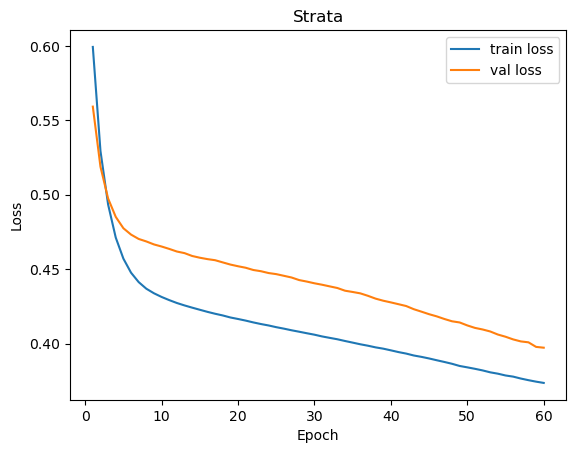

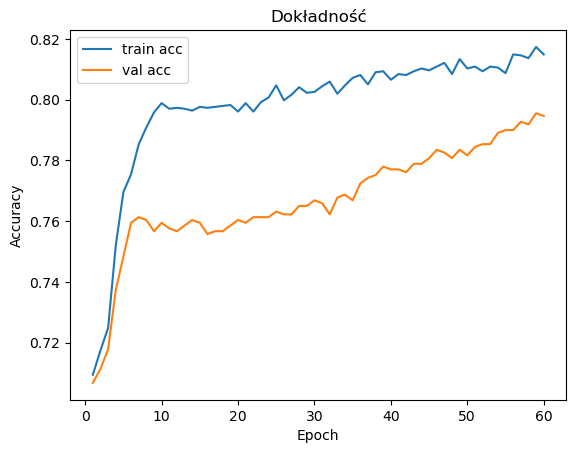

Najlepsza epoka (wg walidacji): 59
Najlepsza dokładność walidacyjna: 0.7955596446990967
Dokładność trening: 0.8167797923088074
Dokładność walidacja: 0.7946345806121826
Dokładność test: 0.802960216999054


In [47]:
## 5.
import numpy as np
import tensorflow
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers

# a) Wczytanie danych z OpenML
X, y = fetch_openml(name="phoneme", version=1, as_frame=False, return_X_y=True)

# Kodowanie etykiet (jeśli są tekstowe)
le = LabelEncoder()
y = le.fit_transform(y)

# Standaryzacja cech
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Podział: train / val / test (60 / 20 / 20)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp
)  # 0.25 * 0.8 = 0.2

num_classes = len(np.unique(y))

# b) Model: 2 warstwy ukryte po 20 neuronów, optymalizator SGD
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(20, activation="relu"),
    layers.Dense(20, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Trening
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    verbose=2
)

# Wykresy: strata i dokładność
epochs = range(1, len(history.history["loss"]) + 1)

plt.figure()
plt.plot(epochs, history.history["loss"], label="train loss")
plt.plot(epochs, history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Strata")
plt.show()

plt.figure()
plt.plot(epochs, history.history["accuracy"], label="train acc")
plt.plot(epochs, history.history["val_accuracy"], label="val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Dokładność")
plt.show()

# Najlepsza epoka wg walidacji
best_epoch = np.argmax(history.history["val_accuracy"]) + 1
best_val_acc = np.max(history.history["val_accuracy"])

print("Najlepsza epoka (wg walidacji):", best_epoch)
print("Najlepsza dokładność walidacyjna:", best_val_acc)

# Test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

print("Dokładność trening:", train_acc)
print("Dokładność walidacja:", val_acc)
print("Dokładność test:", test_acc)